# 01 - LQR, Value Function, and Riccati

Teaching rhythm: try -> observe -> derive/iterate -> exact solution -> limitation -> next method.

We start with the scalar system as a microscope and then move to the double integrator benchmark.
        

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are, solve_discrete_lyapunov

np.set_printoptions(precision=4, suppress=True)
        

## 1) Scalar system and open-loop behavior

System: x[k+1] = x[k] + u[k], with q = 1 and r = 1.
We first run an explicit open-loop simulation and accumulate the cost in a visible loop.
        

Open-loop finite-horizon cost J = 94.4375


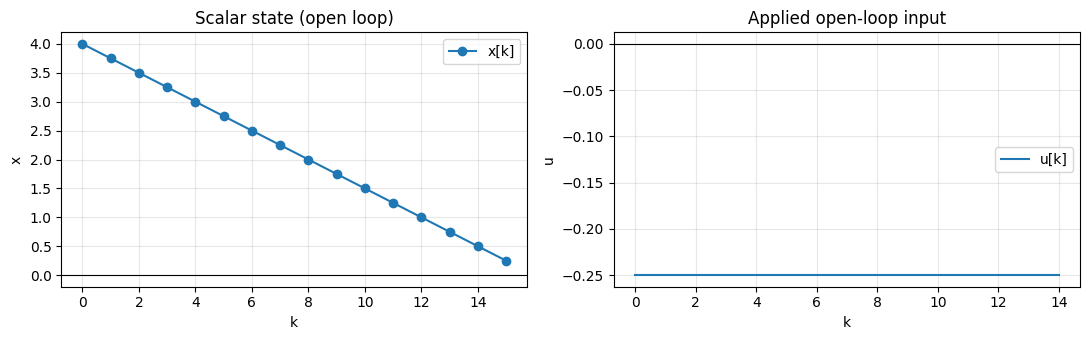

In [2]:
a = 1.0
b = 1.0
q = 1.0
r = 1.0

N_open = 15
x0_scalar = 4.0
u_open = -0.25 * np.ones(N_open)

x_open = np.zeros(N_open + 1)
x_open[0] = x0_scalar
J_open = 0.0

for k in range(N_open):
    J_open += q * x_open[k] ** 2 + r * u_open[k] ** 2
    x_open[k + 1] = a * x_open[k] + b * u_open[k]
J_open += q * x_open[-1] ** 2

print(f'Open-loop finite-horizon cost J = {J_open:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(x_open, 'o-', label='x[k]')
ax[0].axhline(0.0, color='k', linewidth=0.8)
ax[0].set_title('Scalar state (open loop)')
ax[0].set_xlabel('k')
ax[0].set_ylabel('x')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].step(range(N_open), u_open, where='post', label='u[k]')
ax[1].axhline(0.0, color='k', linewidth=0.8)
ax[1].set_title('Applied open-loop input')
ax[1].set_xlabel('k')
ax[1].set_ylabel('u')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()
        

## 2) Try manual feedback u = -K x

Now we keep the same model and run one explicit closed-loop simulation for a hand-picked gain.
        

Manual feedback gain K = 0.450, finite-horizon cost J = 27.5842


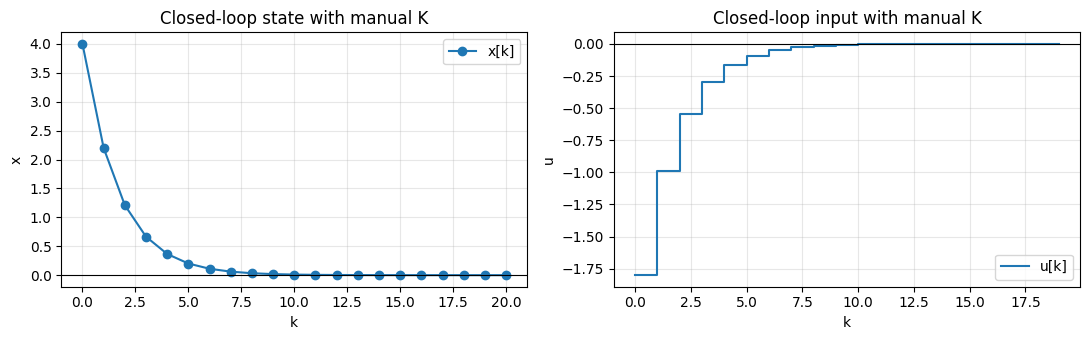

In [3]:
K_manual = 0.45
N_fb = 20

x_fb = np.zeros(N_fb + 1)
u_fb = np.zeros(N_fb)
x_fb[0] = x0_scalar
J_fb = 0.0

for k in range(N_fb):
    u_fb[k] = -K_manual * x_fb[k]
    J_fb += q * x_fb[k] ** 2 + r * u_fb[k] ** 2
    x_fb[k + 1] = a * x_fb[k] + b * u_fb[k]
J_fb += q * x_fb[-1] ** 2

print(f'Manual feedback gain K = {K_manual:.3f}, finite-horizon cost J = {J_fb:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(x_fb, 'o-', label='x[k]')
ax[0].axhline(0.0, color='k', linewidth=0.8)
ax[0].set_title('Closed-loop state with manual K')
ax[0].set_xlabel('k')
ax[0].set_ylabel('x')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].step(range(N_fb), u_fb, where='post', label='u[k]')
ax[1].axhline(0.0, color='k', linewidth=0.8)
ax[1].set_title('Closed-loop input with manual K')
ax[1].set_xlabel('k')
ax[1].set_ylabel('u')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()
        

## 3) Feedback gain matters

We try several gains K, simulate each one explicitly, and compare finite simulation cost.
        

Best K on this finite scan: K = 0.600, J = 25.9048


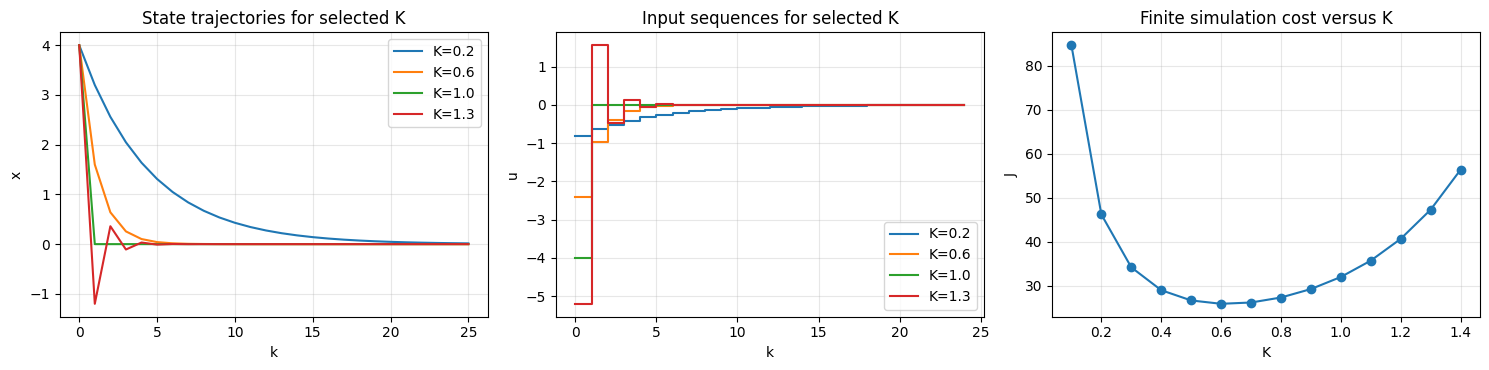

In [4]:
K_values = np.linspace(0.1, 1.4, 14)
N_scan = 25

costs = []
trajectories = {}
inputs = {}

for K in K_values:
    x = np.zeros(N_scan + 1)
    u = np.zeros(N_scan)
    x[0] = x0_scalar
    J = 0.0

    for k in range(N_scan):
        u[k] = -K * x[k]
        J += q * x[k] ** 2 + r * u[k] ** 2
        x[k + 1] = a * x[k] + b * u[k]
    J += q * x[-1] ** 2

    costs.append(J)
    trajectories[K] = x
    inputs[K] = u

best_idx = int(np.argmin(costs))
print(f'Best K on this finite scan: K = {K_values[best_idx]:.3f}, J = {costs[best_idx]:.4f}')

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
selected_demo_gains = [0.2, 0.6, 1.0, 1.3]
for K_demo in selected_demo_gains:
    idx = int(np.argmin(np.abs(K_values - K_demo)))
    K_key = float(K_values[idx])
    ax[0].plot(trajectories[K_key], label=f'K={K_key:.1f}')
ax[0].set_title('State trajectories for selected K')
ax[0].set_xlabel('k')
ax[0].set_ylabel('x')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

for K_demo in selected_demo_gains:
    idx = int(np.argmin(np.abs(K_values - K_demo)))
    K_key = float(K_values[idx])
    ax[1].step(range(N_scan), inputs[K_key], where='post', label=f'K={K_key:.1f}')
ax[1].set_title('Input sequences for selected K')
ax[1].set_xlabel('k')
ax[1].set_ylabel('u')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

ax[2].plot(K_values, costs, 'o-')
ax[2].set_title('Finite simulation cost versus K')
ax[2].set_xlabel('K')
ax[2].set_ylabel('J')
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
        

## 4) Value-function idea in scalar form

For the scalar case we use J*(x) = p x^2. The unknown p is the value-function coefficient.
        

In [5]:
print('Scalar value-function ansatz: J*(x) = p x^2')
print('Now we iterate directly on p using the scalar Riccati update.')
        

Scalar value-function ansatz: J*(x) = p x^2
Now we iterate directly on p using the scalar Riccati update.


## 5) Scalar value iteration

For a = b = q = r = 1, the update is:

p_next = q + a^2 p - (a b p)^2 / (r + b^2 p)

At each step we also compute the associated gain
K = (b p a) / (r + b^2 p).
        

Value iteration final p = 1.6180339887
Value iteration final K = 0.6180339887


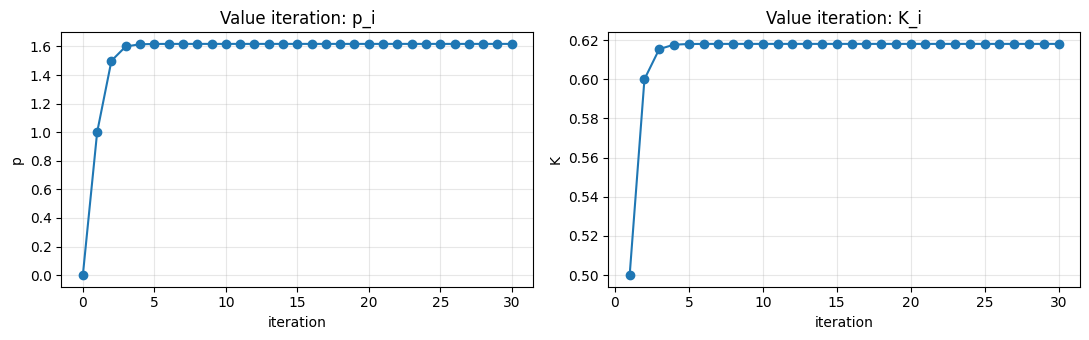

In [6]:
num_vi = 30
p = 0.0

p_hist_vi = [p]
K_hist_vi = []

for _ in range(num_vi):
    p_next = q + a * a * p - (a * b * p) ** 2 / (r + b * b * p)
    K_next = (b * p_next * a) / (r + b * b * p_next)
    p_hist_vi.append(p_next)
    K_hist_vi.append(K_next)
    p = p_next

print(f'Value iteration final p = {p_hist_vi[-1]:.10f}')
print(f'Value iteration final K = {K_hist_vi[-1]:.10f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(p_hist_vi, 'o-')
ax[0].set_title('Value iteration: p_i')
ax[0].set_xlabel('iteration')
ax[0].set_ylabel('p')
ax[0].grid(True, alpha=0.3)

ax[1].plot(range(1, len(K_hist_vi) + 1), K_hist_vi, 'o-')
ax[1].set_title('Value iteration: K_i')
ax[1].set_xlabel('iteration')
ax[1].set_ylabel('K')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
        

## 6) Scalar policy iteration

Policy evaluation for a fixed stabilizing K:

p_K = (q + r K^2) / (1 - (a - b K)^2)

Policy improvement:

K_new = (b p_K a) / (r + b^2 p_K)
        

Policy iteration final p = 1.6180339887
Policy iteration final K = 0.6180339887


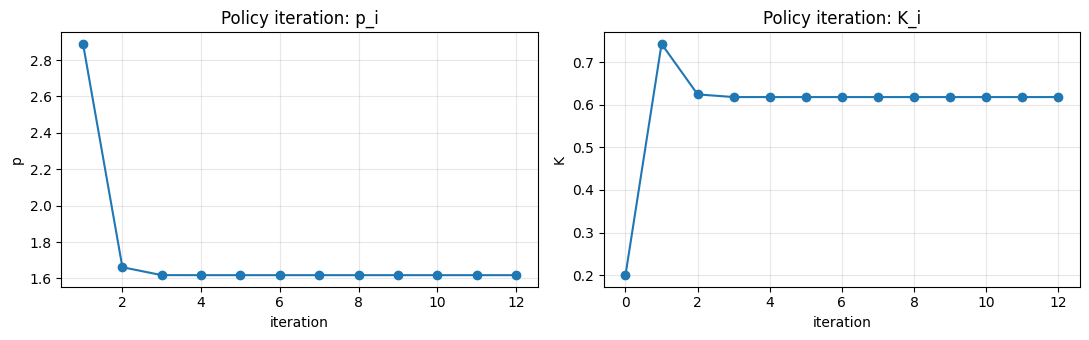

In [7]:
K = 0.2
K_hist_pi = [K]
p_hist_pi = []

for _ in range(12):
    closed_loop_factor = a - b * K
    if abs(closed_loop_factor) >= 1.0:
        raise ValueError('Policy iteration requires a stabilizing K for evaluation.')

    p_K = (q + r * K ** 2) / (1.0 - closed_loop_factor ** 2)
    K_new = (b * p_K * a) / (r + b * b * p_K)

    p_hist_pi.append(p_K)
    K_hist_pi.append(K_new)
    K = K_new

print(f'Policy iteration final p = {p_hist_pi[-1]:.10f}')
print(f'Policy iteration final K = {K_hist_pi[-1]:.10f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(range(1, len(p_hist_pi) + 1), p_hist_pi, 'o-')
ax[0].set_title('Policy iteration: p_i')
ax[0].set_xlabel('iteration')
ax[0].set_ylabel('p')
ax[0].grid(True, alpha=0.3)

ax[1].plot(K_hist_pi, 'o-')
ax[1].set_title('Policy iteration: K_i')
ax[1].set_xlabel('iteration')
ax[1].set_ylabel('K')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
        

## 7) Exact scalar DARE solution and agreement check

For q = r = 1 and a = b = 1, the scalar DARE reduces to

p^2 - q p - q r = 0.

We use the positive root and compare with value iteration and policy iteration.
        

In [8]:
p_exact = 0.5 * (q + np.sqrt(q ** 2 + 4.0 * q * r))
K_exact = (b * p_exact * a) / (r + b * b * p_exact)

p_vi = p_hist_vi[-1]
K_vi = K_hist_vi[-1]
p_pi = p_hist_pi[-1]
K_pi = K_hist_pi[-1]

print(f'Exact root p*      = {p_exact:.10f}')
print(f'Value iteration p  = {p_vi:.10f}')
print(f'Policy iteration p = {p_pi:.10f}')
print('---')
print(f'Exact gain K*      = {K_exact:.10f}')
print(f'Value iteration K  = {K_vi:.10f}')
print(f'Policy iteration K = {K_pi:.10f}')

assert np.isclose(p_vi, p_exact, atol=1e-8)
assert np.isclose(p_pi, p_exact, atol=1e-8)
assert np.isclose(K_vi, K_exact, atol=1e-8)
assert np.isclose(K_pi, K_exact, atol=1e-8)

print('Check passed: value iteration, policy iteration, and exact scalar solution agree.')
        

Exact root p*      = 1.6180339887
Value iteration p  = 1.6180339887
Policy iteration p = 1.6180339887
---
Exact gain K*      = 0.6180339887
Value iteration K  = 0.6180339887
Policy iteration K = 0.6180339887
Check passed: value iteration, policy iteration, and exact scalar solution agree.


## 8) Move to matrix benchmark: double integrator

We now switch to the board-friendly double integrator and keep all matrices visible.
        

A =
[[1. 1.]
 [0. 1.]]
B =
[[0.]
 [1.]]
Q =
[[4. 0.]
 [0. 1.]]
R =
[[0.2]]
x0 = [3.  0.8]


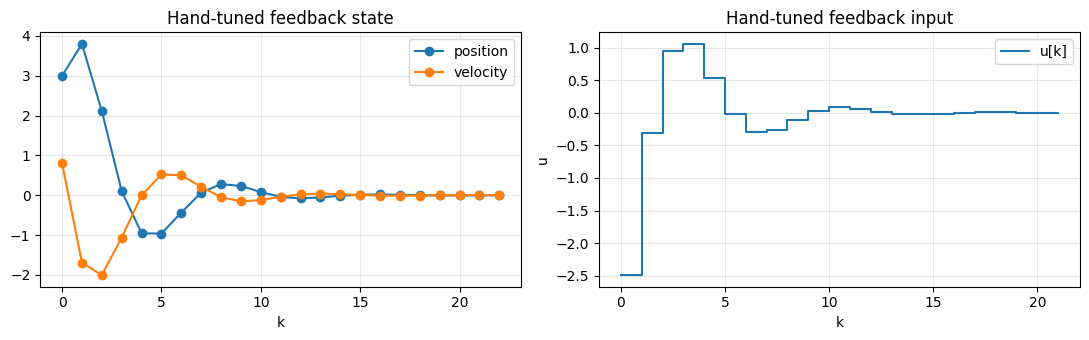

In [9]:
A = np.array([[1.0, 1.0],
              [0.0, 1.0]])
B = np.array([[0.0],
              [1.0]])
Q = np.diag([4.0, 1.0])
R = np.array([[0.2]])
x0 = np.array([3.0, 0.8])

print('A =')
print(A)
print('B =')
print(B)
print('Q =')
print(Q)
print('R =')
print(R)
print('x0 =', x0)

# Hand-tuned feedback for orientation before exact LQR.
K_hand = np.array([[0.55, 1.05]])
steps_hand = 22
x_hand = np.zeros((steps_hand + 1, 2))
u_hand = np.zeros(steps_hand)
x_hand[0] = x0

for k in range(steps_hand):
    u_hand[k] = float(-(K_hand @ x_hand[k]).item())
    x_hand[k + 1] = A @ x_hand[k] + (B[:, 0] * u_hand[k])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(x_hand[:, 0], 'o-', label='position')
ax[0].plot(x_hand[:, 1], 'o-', label='velocity')
ax[0].set_title('Hand-tuned feedback state')
ax[0].set_xlabel('k')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].step(range(steps_hand), u_hand, where='post', label='u[k]')
ax[1].set_title('Hand-tuned feedback input')
ax[1].set_xlabel('k')
ax[1].set_ylabel('u')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()
        

## 9) Exact matrix LQR from DARE

Compute P_inf from scipy.linalg.solve_discrete_are and then
K_inf = inv(R + B.T P_inf B) (B.T P_inf A).
        

In [10]:
P_inf = solve_discrete_are(A, B, Q, R)
K_inf = np.linalg.solve(R + B.T @ P_inf @ B, B.T @ P_inf @ A)

print('P_inf =')
print(P_inf)
print('K_inf =')
print(K_inf)
print('Spectral radius of A-BK_inf =', np.max(np.abs(np.linalg.eigvals(A - B @ K_inf))))
        

P_inf =
[[9.0385 5.1926]
 [5.1926 6.5407]]
K_inf =
[[0.7703 1.7407]]
Spectral radius of A-BK_inf = 0.17225121928467124


## 10) Matrix Riccati iteration

We now iterate P explicitly and watch entries of P and K converge to the DARE solution.
        

||P_riccati - P_inf||_F = 1.854570987253821e-14
||K_riccati - K_inf||_F = 1.4936523181711914e-15
Check passed: matrix Riccati iteration converged to DARE solution.


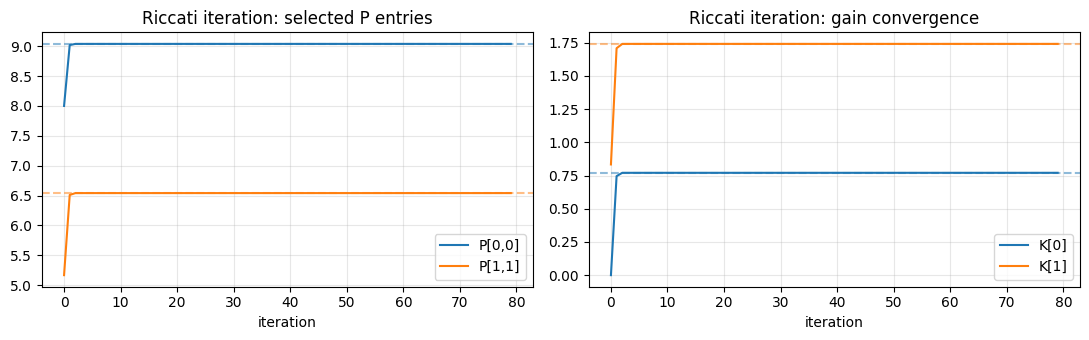

In [11]:
P = Q.copy()
P_hist = []
K_hist = []

for _ in range(80):
    K = np.linalg.solve(R + B.T @ P @ B, B.T @ P @ A)
    P_next = Q + A.T @ P @ A - A.T @ P @ B @ K
    P_hist.append(P_next.copy())
    K_hist.append(K.copy())
    P = P_next

P_riccati = P_hist[-1]
K_riccati = K_hist[-1]

print('||P_riccati - P_inf||_F =', np.linalg.norm(P_riccati - P_inf))
print('||K_riccati - K_inf||_F =', np.linalg.norm(K_riccati - K_inf))

assert np.allclose(P_riccati, P_inf, atol=1e-7)
assert np.allclose(K_riccati, K_inf, atol=1e-7)
print('Check passed: matrix Riccati iteration converged to DARE solution.')

P00 = [Pk[0, 0] for Pk in P_hist]
P11 = [Pk[1, 1] for Pk in P_hist]
K0 = [Kk[0, 0] for Kk in K_hist]
K1 = [Kk[0, 1] for Kk in K_hist]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(P00, label='P[0,0]')
ax[0].plot(P11, label='P[1,1]')
ax[0].axhline(P_inf[0, 0], color='C0', linestyle='--', alpha=0.5)
ax[0].axhline(P_inf[1, 1], color='C1', linestyle='--', alpha=0.5)
ax[0].set_title('Riccati iteration: selected P entries')
ax[0].set_xlabel('iteration')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(K0, label='K[0]')
ax[1].plot(K1, label='K[1]')
ax[1].axhline(K_inf[0, 0], color='C0', linestyle='--', alpha=0.5)
ax[1].axhline(K_inf[0, 1], color='C1', linestyle='--', alpha=0.5)
ax[1].set_title('Riccati iteration: gain convergence')
ax[1].set_xlabel('iteration')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()
        

## 11) Compact matrix policy iteration (optional)

Policy evaluation uses the discrete Lyapunov equation for a fixed stabilizing K,
then policy improvement updates K.
        

In [12]:
K_pi_mat = np.array([[0.8, 1.2]])
K_pi_hist = [K_pi_mat.copy()]
P_pi_hist = []

for _ in range(12):
    Acl = A - B @ K_pi_mat
    if np.max(np.abs(np.linalg.eigvals(Acl))) >= 1.0:
        raise ValueError('Current K is not stabilizing; policy evaluation not valid.')

    P_eval = solve_discrete_lyapunov(Acl.T, Q + K_pi_mat.T @ R @ K_pi_mat)
    K_pi_mat = np.linalg.solve(R + B.T @ P_eval @ B, B.T @ P_eval @ A)

    P_pi_hist.append(P_eval.copy())
    K_pi_hist.append(K_pi_mat.copy())

print('Final policy-iteration gain K =')
print(K_pi_hist[-1])
print('Reference gain K_inf =')
print(K_inf)
print('||K_pi - K_inf||_F =', np.linalg.norm(K_pi_hist[-1] - K_inf))
        

Final policy-iteration gain K =
[[0.7703 1.7407]]
Reference gain K_inf =
[[0.7703 1.7407]]
||K_pi - K_inf||_F = 1.336885555457667e-15


## 12) LQR closed-loop simulation and cost interpretation

We now simulate u = -K_inf x and compute finite simulation cost.
The value-function interpretation is J*(x) = x.T P_inf x.
        

LQR finite cost (with terminal P_inf term) = 142.7963
Initial optimal value prediction x0^T P_inf x0 = 142.7963


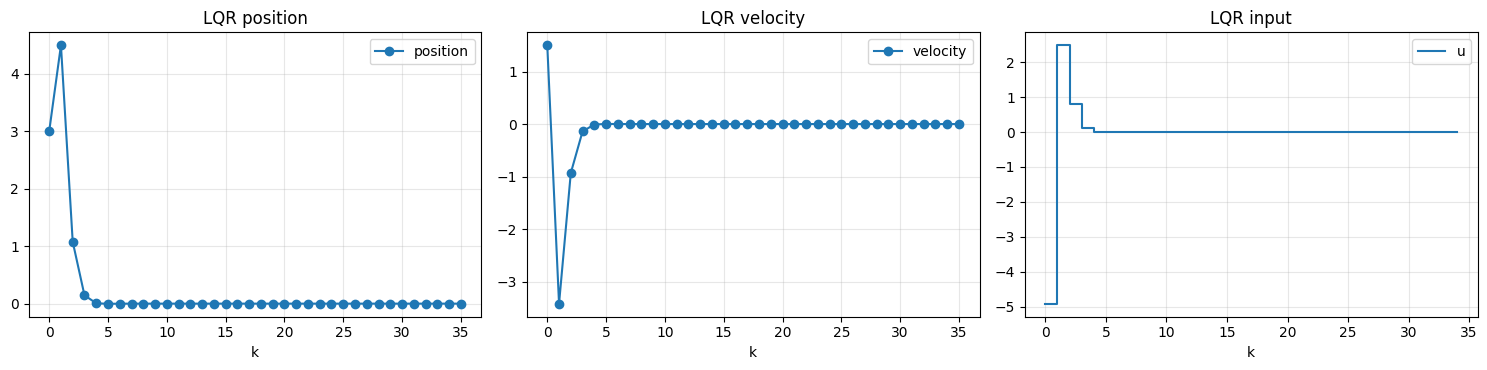

In [13]:
steps_lqr = 35
x_lqr = np.zeros((steps_lqr + 1, 2))
u_lqr = np.zeros(steps_lqr)
x_lqr[0] = np.array([3.0, 1.5])
J_lqr = 0.0

for k in range(steps_lqr):
    u_lqr[k] = float(-(K_inf @ x_lqr[k]).item())
    J_lqr += x_lqr[k] @ Q @ x_lqr[k] + u_lqr[k] * (R[0, 0] * u_lqr[k])
    x_lqr[k + 1] = A @ x_lqr[k] + B[:, 0] * u_lqr[k]
J_lqr += x_lqr[-1] @ P_inf @ x_lqr[-1]

print(f'LQR finite cost (with terminal P_inf term) = {J_lqr:.4f}')
print(f'Initial optimal value prediction x0^T P_inf x0 = {(x_lqr[0] @ P_inf @ x_lqr[0]):.4f}')

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].plot(x_lqr[:, 0], 'o-', label='position')
ax[0].set_title('LQR position')
ax[0].set_xlabel('k')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(x_lqr[:, 1], 'o-', label='velocity')
ax[1].set_title('LQR velocity')
ax[1].set_xlabel('k')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

ax[2].step(range(steps_lqr), u_lqr, where='post', label='u')
ax[2].set_title('LQR input')
ax[2].set_xlabel('k')
ax[2].grid(True, alpha=0.3)
ax[2].legend()

plt.tight_layout()
plt.show()
        

## 13) Limitation: input saturation

Now we clip the LQR input u = clip(-K_inf x, -u_max, u_max).
This is easy to implement, but it is not the principled constrained optimum.
        

Unconstrained LQR cost surrogate: 142.7963
Saturated LQR cost surrogate:    509.2002


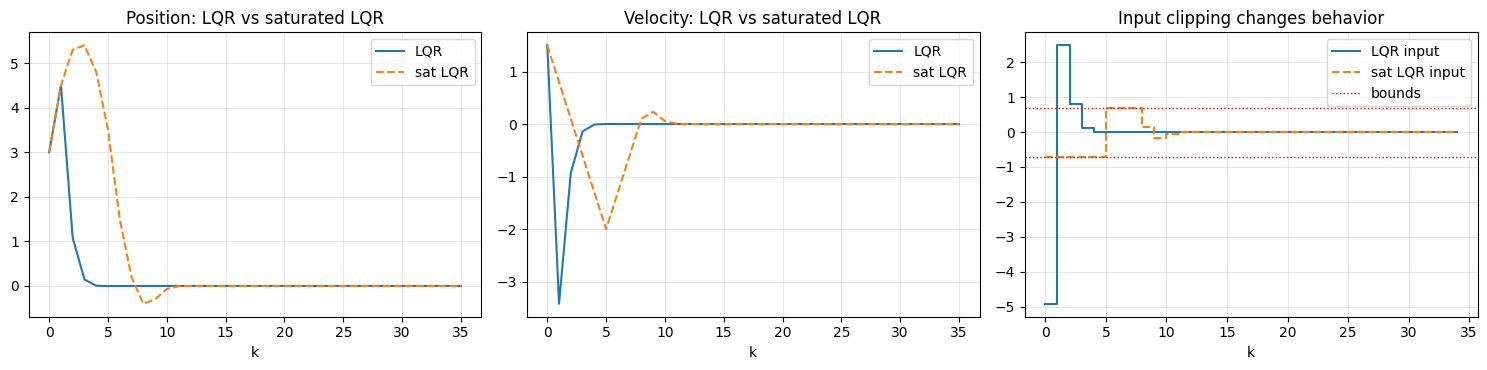

In [14]:
u_max = 0.7

x_sat = np.zeros((steps_lqr + 1, 2))
u_sat = np.zeros(steps_lqr)
x_sat[0] = x_lqr[0].copy()
J_sat = 0.0

for k in range(steps_lqr):
    u_nom = float(-(K_inf @ x_sat[k]).item())
    u_sat[k] = np.clip(u_nom, -u_max, u_max)
    J_sat += x_sat[k] @ Q @ x_sat[k] + u_sat[k] * (R[0, 0] * u_sat[k])
    x_sat[k + 1] = A @ x_sat[k] + B[:, 0] * u_sat[k]
J_sat += x_sat[-1] @ P_inf @ x_sat[-1]

print(f'Unconstrained LQR cost surrogate: {J_lqr:.4f}')
print(f'Saturated LQR cost surrogate:    {J_sat:.4f}')

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].plot(x_lqr[:, 0], label='LQR')
ax[0].plot(x_sat[:, 0], '--', label='sat LQR')
ax[0].set_title('Position: LQR vs saturated LQR')
ax[0].set_xlabel('k')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(x_lqr[:, 1], label='LQR')
ax[1].plot(x_sat[:, 1], '--', label='sat LQR')
ax[1].set_title('Velocity: LQR vs saturated LQR')
ax[1].set_xlabel('k')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

ax[2].step(range(steps_lqr), u_lqr, where='post', label='LQR input')
ax[2].step(range(steps_lqr), u_sat, where='post', linestyle='--', label='sat LQR input')
ax[2].axhline(u_max, color='r', linestyle=':', linewidth=1.0, label='bounds')
ax[2].axhline(-u_max, color='r', linestyle=':', linewidth=1.0)
ax[2].set_title('Input clipping changes behavior')
ax[2].set_xlabel('k')
ax[2].grid(True, alpha=0.3)
ax[2].legend()

plt.tight_layout()
plt.show()
        

## Takeaway

Value iteration, policy iteration, and the exact DARE agree on the unconstrained optimum.

With hard input limits, clipping u = -K_inf x is only a workaround. In the next notebook we formulate constrained finite-horizon optimization directly, which leads to MPC.
        